# Wine — random forest + importances

Daily notebook — small experiment, fully reproducible (seed pinned below).

13 chemical features, 3 cultivars. RF baseline and which features matter.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)

from sklearn.datasets import load_wine


## Data

In [ ]:
SEED = 1302
X, y = load_wine(return_X_y=True, as_frame=True)
print("shape:", X.shape)
print(pd.Series(y).value_counts().sort_index().to_string())


shape: (178, 13)
target
0    59
1    71
2    48


## Model

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y)
rf = RandomForestClassifier(n_estimators=400, random_state=SEED, n_jobs=1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, pred):.4f}")
print(f"oob score: {RandomForestClassifier(n_estimators=400, oob_score=True, random_state=SEED, n_jobs=1).fit(X, y).oob_score_:.4f}")


accuracy: 0.9815
oob score: 0.9775


## Feature importances

top: proline (0.183)


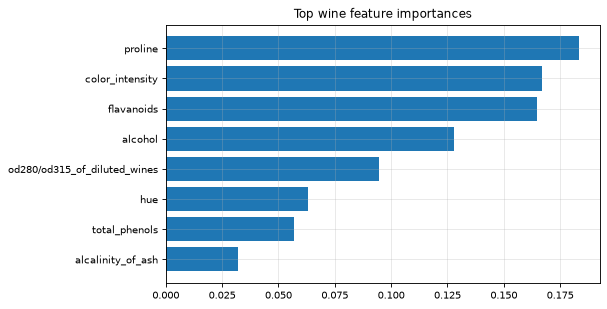

In [ ]:

imp = rf.feature_importances_
order = np.argsort(imp)[::-1][:8]
fig, ax = plt.subplots()
ax.barh(X.columns[order][::-1], imp[order][::-1])
ax.set_title("Top wine feature importances")
print("top:", X.columns[order[0]], f"({imp[order[0]]:.3f})")


## Confusion matrix

plotted confusion matrix


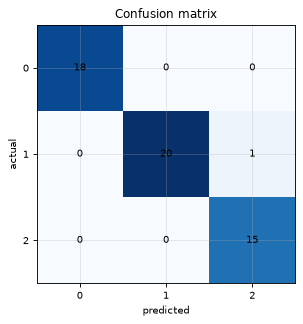

In [ ]:

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots()
ax.imshow(cm, cmap="Blues")
k = cm.shape[0]
ax.set_xticks(range(k)); ax.set_yticks(range(k))
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Confusion matrix")
for i in range(k):
    for j in range(k):
        ax.text(j, i, cm[i, j], ha="center", va="center")
print("plotted confusion matrix")


## Takeaways

- Flavanoids/proline dominate — the chemistry story checks out.
- Small dataset, so the CV variance is real; don't over-read 0.98 vs 1.0.